# Modelos de supervivencia: Cox PH y AFT

## Objetivo 

El objetivo de este notebook es ajustar los primeros modelos estadísticos de supervivencia para estudiar el tiempo hasta entrada de genéricos.

En los notebooks anteriores se construyeron dos etapas del proyecto:

1. `01_ingesta_orangebook_drugsfda.ipynb`  
   - lectura de Orange Book y Drugs@FDA;
   - limpieza de llaves;
   - construcción de una cohorte preliminar ingrediente--forma--ruta;
   - definición del endpoint;
   - estimación de una curva Kaplan--Meier global.

2. `02_patentes_exclusividades_endpoint.ipynb`  
   - integración de patentes;
   - integración de exclusividades regulatorias;
   - construcción de la base enriquecida `survival_v2`;
   - comparación Kaplan--Meier por subgrupos regulatorios.

En este tercer notebook se ajustarán modelos de supervivencia usando la base:

```text
data_intermediate/survival_analysis_v2_patents_exclusivities.parquet

### Pregunta estadística

La pregunta principal es:

### ¿Qué características regulatorias y de producto se asocian con mayor o menor riesgo de entrada de genéricos?

En términos de supervivencia, el evento es:

```text
entrada del primer genérico comparable
```

y el tiempo de seguimiento es:

```text
años desde la aprobación del innovador candidato hasta el primer genérico o censura
```



## Modelos principales

### 1. Modelo Cox proporcional de riesgos

El modelo Cox permite estimar el efecto de covariables sobre el hazard de entrada de genéricos:

$$
h(t \mid X) = h_0(t)\exp(\beta^\top X).
$$

La interpretación se hace mediante razones de riesgo o hazard ratios:

$$
HR = \exp(\beta).
$$

En este proyecto:

* `HR > 1` indica mayor riesgo instantáneo de entrada de genérico, es decir, entrada más rápida.
* `HR < 1` indica menor riesgo instantáneo de entrada de genérico, es decir, entrada más tardía.

Por ejemplo, si `has_patent` tiene `HR < 1`, eso sugeriría que las unidades con patente tienen menor hazard de entrada genérica y, por tanto, tienden a permanecer más tiempo sin genérico.



### 2. Modelos AFT

Los modelos AFT, o accelerated failure time, modelan directamente el logaritmo del tiempo al evento:

$$
\log(T) = \alpha + \gamma^\top X + \sigma\varepsilon.
$$

Su interpretación se hace mediante factores de aceleración del tiempo. En términos prácticos:

* un factor mayor que 1 sugiere tiempos más largos hasta genérico;
* un factor menor que 1 sugiere tiempos más cortos hasta genérico.

En este notebook se intentarán modelos AFT como Weibull y Log-Logistic, dependiendo de la disponibilidad de `lifelines`.



## Covariables iniciales

En esta primera versión se usarán covariables regulatorias simples:

* `has_patent`;
* `has_drug_substance_patent`;
* `has_drug_product_patent`;
* `has_patent_use_code`;
* `has_exclusivity`;
* `n_patents`;
* `n_exclusivities`;
* `approval_year`.

También se explorarán algunas variables categóricas de producto, como:

* `route`;
* `dosage_form`.

Para evitar modelos demasiado grandes en esta primera versión, se agruparán rutas o formas poco frecuentes en una categoría `OTHER`.



## Advertencias de interpretación

Este notebook tiene carácter exploratorio. Los modelos no deben interpretarse todavía como evidencia causal.

Hay varias razones:

1. La cohorte todavía es preliminar y está definida a nivel ingrediente--forma--ruta.
2. Las variables de patentes y exclusividades provienen de la versión actual del Orange Book.
3. Puede haber confusión por año de aprobación, tipo de producto, ruta, mercado o clase terapéutica.
4. Algunas variables regulatorias están correlacionadas entre sí.
5. La identificación de primer genérico todavía usa una regla operativa inicial.

Aun así, estos modelos permitirán evaluar si el pipeline estadístico funciona y qué variables parecen más relevantes para versiones posteriores del análisis.

Se revisarán supuestos básicos del modelo Cox, especialmente la proporcionalidad de riesgos.


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


# Rutas principales

PROJECT_DIR = Path.cwd()

DATA_INTERMEDIATE_DIR = PROJECT_DIR / "data_intermediate"
DATA_FINAL_DIR = PROJECT_DIR / "data_final"
FIGURES_DIR = PROJECT_DIR / "figures"
TABLES_DIR = PROJECT_DIR / "tables"

for folder in [DATA_INTERMEDIATE_DIR, DATA_FINAL_DIR, FIGURES_DIR, TABLES_DIR]:
    folder.mkdir(exist_ok=True)


# Cargar base enriquecida

survival_v2_path = DATA_INTERMEDIATE_DIR / "survival_analysis_v2_patents_exclusivities.parquet"

survival_v2 = pd.read_parquet(survival_v2_path)

print("=" * 80)
print("Base enriquecida cargada correctamente")
print("=" * 80)

print(f"Ruta: {survival_v2_path}")
print(f"Filas: {survival_v2.shape[0]:,}")
print(f"Columnas: {survival_v2.shape[1]:,}")

print("\nPrimeras columnas:")
print(list(survival_v2.columns[:25]))

print("\nColumnas restantes:")
print(list(survival_v2.columns[25:]))


# Verificar columnas esenciales

required_cols = [
    "time_to_generic_years",
    "event",
    "approval_year",
    "has_patent",
    "has_drug_substance_patent",
    "has_drug_product_patent",
    "has_patent_use_code",
    "has_exclusivity",
    "n_patents",
    "n_exclusivities",
    "route",
    "dosage_form"
]

missing_cols = [col for col in required_cols if col not in survival_v2.columns]

print("\n" + "=" * 80)
print("Verificación de columnas esenciales")
print("=" * 80)

if missing_cols:
    print("Columnas faltantes:")
    print(missing_cols)
else:
    print("Todas las columnas esenciales están presentes.")

print("\nResumen básico del endpoint:")
display(
    survival_v2[["time_to_generic_years", "event", "approval_year"]]
    .describe()
)

print("\nEventos y censuras:")
display(
    survival_v2["event"]
    .value_counts()
    .rename_axis("event")
    .reset_index(name="n")
)

Base enriquecida cargada correctamente
Ruta: /Users/juanalbertomartinez/Desktop/Patente/data_intermediate/survival_analysis_v2_patents_exclusivities.parquet
Filas: 1,439
Columnas: 46

Primeras columnas:
['ingredient', 'dosage_form', 'route', 'nme_approval_date', 'approval_year', 'innovator_appl_no', 'innovator_product_no', 'innovator_trade_name', 'first_generic_approval_date', 'first_generic_appl_no', 'first_generic_product_no', 'first_generic_trade_name', 'first_generic_te_code', 'event', 'end_date', 'time_to_generic_years', 'n_nda_products', 'n_nda_applications', 'n_anda_products_total', 'n_anda_applications_total', 'ingredient_key', 'dosage_form_key', 'route_key', 'n_patents', 'n_patent_records']

Columnas restantes:
['patent_expiry_min', 'patent_expiry_max', 'has_drug_substance_patent', 'has_drug_product_patent', 'has_patent_use_code', 'has_delist_flag', 'patent_use_codes', 'patent_numbers', 'has_patent', 'n_exclusivities', 'n_exclusivity_records', 'exclusivity_expiry_min', 'exclus

,time_to_generic_years,event,approval_year
count,1439.000000,1439.000000,1439.000000
mean,11.285602,0.596942,2008.244614
std,5.868447,0.490683,6.381470
min,0.093087,0.000000,1998.000000
25%,7.411362,0.000000,2003.000000
50%,10.313484,1.000000,2008.000000
75%,14.506502,1.000000,2014.000000
max,28.246407,1.000000,2018.000000



Eventos y censuras:


,event,n
0,1,859
1,0,580


### Interpretación de la carga de la base enriquecida

La base enriquecida `survival_v2` fue cargada correctamente desde el archivo generado en el notebook anterior.

La base contiene:

- 1,439 unidades ingrediente--forma--ruta;
- 46 columnas;
- 859 eventos observados;
- 580 observaciones censuradas.

También se verificó que todas las columnas esenciales para modelado están presentes. En particular, contamos con:

- `time_to_generic_years`: tiempo hasta genérico o censura;
- `event`: indicador de entrada de genérico;
- `approval_year`: año de aprobación del innovador candidato;
- variables regulatorias de patentes;
- variables regulatorias de exclusividades;
- variables de producto como ruta y forma farmacéutica.

El resumen del endpoint coincide con los notebooks anteriores. La mediana del tiempo observado es aproximadamente 10.31 años, y la base cubre aprobaciones entre 1998 y 2018.

Con esto queda confirmado que el tercer notebook puede comenzar el proceso de modelado. El siguiente paso será preparar una matriz de variables para Cox y AFT, convirtiendo variables booleanas y categóricas a un formato adecuado.

## 2. Preparación del dataset de modelado

Antes de ajustar modelos Cox o AFT, es necesario preparar una base de modelado con variables numéricas y categóricas codificadas.

En esta primera versión usaremos tres tipos de covariables:

### Variables regulatorias binarias

- `has_patent`
- `has_drug_substance_patent`
- `has_drug_product_patent`
- `has_patent_use_code`
- `has_exclusivity`

Estas variables se convertirán a enteros `0/1`.

### Variables regulatorias numéricas

- `n_patents`
- `n_exclusivities`

Como el número de patentes tiene una distribución asimétrica, también construiremos:

- `log1p_n_patents = log(1 + n_patents)`

Esta transformación reduce el peso de productos con carteras de patentes extremadamente grandes.

### Variable temporal

- `approval_year`

Para mejorar la interpretación y estabilidad numérica, se centrará como:

```text
approval_year_centered = approval_year - mediana(approval_year)

In [7]:
# Preparación del dataset de modelado

model_df = survival_v2.copy()

# Variables esenciales

model_df = model_df.loc[
    model_df["time_to_generic_years"].notna()
    & model_df["event"].notna()
    & model_df["approval_year"].notna()
].copy()

# Variables binarias regulatorias

binary_cols = [
    "has_patent",
    "has_drug_substance_patent",
    "has_drug_product_patent",
    "has_patent_use_code",
    "has_exclusivity"
]

for col in binary_cols:
    model_df[col] = model_df[col].fillna(False).astype(bool).astype(int)

# Variables numéricas regulatorias

model_df["n_patents"] = model_df["n_patents"].fillna(0).astype(float)
model_df["n_exclusivities"] = model_df["n_exclusivities"].fillna(0).astype(float)

model_df["log1p_n_patents"] = np.log1p(model_df["n_patents"])
model_df["log1p_n_exclusivities"] = np.log1p(model_df["n_exclusivities"])

# Año de aprobación centrado

approval_year_median = model_df["approval_year"].median()
model_df["approval_year_centered"] = model_df["approval_year"] - approval_year_median

print(f"Mediana de approval_year usada para centrar: {approval_year_median}")

# Ruta de administración simplificada

route_counts = model_df["route"].fillna("UNKNOWN").value_counts()

top_routes = route_counts.head(8).index.tolist()

model_df["route_simplified"] = (
    model_df["route"]
    .fillna("UNKNOWN")
    .where(model_df["route"].fillna("UNKNOWN").isin(top_routes), "OTHER")
)

print("\nRutas conservadas como categorías principales:")
print(top_routes)

print("\nDistribución de route_simplified:")
display(
    model_df["route_simplified"]
    .value_counts()
    .rename_axis("route_simplified")
    .reset_index(name="n")
)

# Dataset base para modelado

base_model_cols = [
    "time_to_generic_years",
    "event",
    "approval_year_centered",
    "has_patent",
    "has_drug_substance_patent",
    "has_drug_product_patent",
    "has_patent_use_code",
    "has_exclusivity",
    "log1p_n_patents",
    "log1p_n_exclusivities",
    "route_simplified"
]

modeling_dataset = model_df[base_model_cols].copy()

print("\n" + "=" * 80)
print("Dataset base de modelado")
print("=" * 80)

print(f"Filas: {modeling_dataset.shape[0]:,}")
print(f"Columnas: {modeling_dataset.shape[1]:,}")

display(modeling_dataset.head(10))

print("\nResumen de variables numéricas:")
display(
    modeling_dataset[
        [
            "time_to_generic_years",
            "event",
            "approval_year_centered",
            "log1p_n_patents",
            "log1p_n_exclusivities"
        ]
    ].describe()
)

Mediana de approval_year usada para centrar: 2008.0

Rutas conservadas como categorías principales:
['ORAL', 'INTRAVENOUS', 'TOPICAL', 'INHALATION', 'INJECTION', 'OPHTHALMIC', 'SUBCUTANEOUS', 'TRANSDERMAL']

Distribución de route_simplified:


,route_simplified,n
0,ORAL,841
1,INTRAVENOUS,157
2,OTHER,134
3,TOPICAL,100
4,INHALATION,51
5,INJECTION,50
6,OPHTHALMIC,49
7,SUBCUTANEOUS,36
8,TRANSDERMAL,21



Dataset base de modelado
Filas: 1,439
Columnas: 11


,time_to_generic_years,event,approval_year_centered,has_patent,has_drug_substance_patent,has_drug_product_patent,has_patent_use_code,has_exclusivity,log1p_n_patents,log1p_n_exclusivities,route_simplified
0,17.776865,1,-10.0,0,0,0,0,0,0.000000,0.000000,ORAL
1,13.503080,1,-10.0,0,0,0,0,0,0.000000,0.000000,ORAL
2,11.630390,0,6.0,1,1,1,0,1,1.609438,1.098612,ORAL
3,12.158795,1,-4.0,0,0,0,0,0,0.000000,0.000000,ORAL
4,13.056810,1,-8.0,0,0,0,0,0,0.000000,0.000000,ORAL
5,8.947296,0,9.0,1,0,1,1,0,2.302585,0.000000,SUBCUTANEOUS
6,8.528405,0,9.0,1,1,1,1,0,0.693147,0.000000,ORAL
7,7.509925,1,3.0,0,0,0,0,0,0.000000,0.000000,ORAL
8,8.438056,0,9.0,1,1,1,1,1,2.302585,1.098612,ORAL
9,8.963723,1,-4.0,0,0,0,0,0,0.000000,0.000000,ORAL



Resumen de variables numéricas:


,time_to_generic_years,event,approval_year_centered,log1p_n_patents,log1p_n_exclusivities
count,1439.000000,1439.000000,1439.000000,1439.000000,1439.000000
mean,11.285602,0.596942,0.244614,0.698209,0.105554
std,5.868447,0.490683,6.381470,0.972281,0.327778
min,0.093087,0.000000,-10.000000,0.000000,0.000000
25%,7.411362,0.000000,-5.000000,0.000000,0.000000
50%,10.313484,1.000000,0.000000,0.000000,0.000000
75%,14.506502,1.000000,6.000000,1.386294,0.000000
max,28.246407,1.000000,10.000000,4.234107,2.079442


### Interpretación de la preparación del dataset de modelado

El dataset de modelado se preparó correctamente y conserva las 1,439 unidades de la base enriquecida.

La variable `approval_year` fue centrada usando como referencia la mediana del año de aprobación, que fue 2008. Por tanto, `approval_year_centered = 0` corresponde a productos aprobados en 2008; valores negativos corresponden a aprobaciones anteriores y valores positivos a aprobaciones posteriores.

También se transformaron las variables regulatorias binarias a formato `0/1`, lo cual permite usarlas directamente en modelos Cox y AFT.

El número de patentes y exclusividades fue transformado mediante:

```text
log1p_n_patents = log(1 + n_patents)
log1p_n_exclusivities = log(1 + n_exclusivities)

Esto es conveniente porque el número de patentes es muy asimétrico: muchos productos no tienen patentes, mientras que algunos tienen carteras extensas.

Para la ruta de administración se conservaron las ocho rutas más frecuentes:

- ORAL
- INTRAVENOUS
- TOPICAL
- INHALATION
- INJECTION
- OPHTHALMIC
- SUBCUTANEOUS
- TRANSDERMAL

Las demás rutas fueron agrupadas como OTHER. Esto reduce la complejidad del modelo y evita categorías con muy pocas observaciones.

La base modeling_dataset queda lista para ajustar modelos de supervivencia. El siguiente paso será ajustar un primer modelo Cox simple con variables regulatorias principales.

## 3. Primer modelo Cox proporcional de riesgos

En esta sección se ajustará un primer modelo Cox proporcional de riesgos usando variables regulatorias principales.

El modelo incluirá:

- `approval_year_centered`;
- `has_patent`;
- `has_exclusivity`;
- `log1p_n_patents`;
- `log1p_n_exclusivities`.

La variable `approval_year_centered` se incluye para ajustar parcialmente por el año de aprobación. Esto es importante porque los productos más recientes tienen menor tiempo de seguimiento y mayor probabilidad de censura.

En el modelo Cox, la interpretación se hace mediante hazard ratios:

```text
HR > 1  : mayor hazard de entrada genérica, es decir, entrada más rápida.
HR < 1  : menor hazard de entrada genérica, es decir, entrada más tardía.
HR = 1  : sin asociación aparente con el hazard.

In [14]:
# Primer modelo Cox proporcional de riesgos

try:
    from lifelines import CoxPHFitter
except ImportError as e:
    raise ImportError(
        "La librería 'lifelines' no está instalada. "
        "Instálala con: pip install lifelines"
    ) from e


cox_simple_cols = [
    "time_to_generic_years",
    "event",
    "approval_year_centered",
    "has_patent",
    "has_exclusivity",
    "log1p_n_patents",
    "log1p_n_exclusivities"
]

cox_simple_df = modeling_dataset[cox_simple_cols].dropna().copy()

print("=" * 80)
print("Dataset para Cox simple")
print("=" * 80)
print(f"Filas: {cox_simple_df.shape[0]:,}")
print(f"Columnas: {cox_simple_df.shape[1]:,}")

# Ajustar Cox
cox_simple = CoxPHFitter()

cox_simple.fit(
    cox_simple_df,
    duration_col="time_to_generic_years",
    event_col="event"
)

print("\n" + "=" * 80)
print("Resumen del modelo Cox simple")
print("=" * 80)

cox_simple.print_summary()

# resumen en dataframe
cox_simple_summary = cox_simple.summary.reset_index().rename(columns={"covariate": "variable"})

print("\nResumen tabular:")
display(
    cox_simple_summary[
        [
            "variable", "coef", "exp(coef)", "se(coef)",
            "z", "p", "coef lower 95%", "coef upper 95%",
            "exp(coef) lower 95%", "exp(coef) upper 95%"
        ]
    ]
)

Dataset para Cox simple
Filas: 1,439
Columnas: 7

Resumen del modelo Cox simple


<lifelines.CoxPHFitter: fitted with 1439 total observations, 580 right-censored observations>
             duration col = 'time_to_generic_years'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1439
number of events observed = 859
   partial log-likelihood = -5642.67
         time fit was run = 2026-06-26 06:27:09 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
approval_year_centered  0.00      1.00      0.01           -0.01            0.02                0.99                1.02
has_patent             -0.51      0.60      0.17           -0.84           -0.18                0.43                0.84
has_exclusivity         0.31      1.37      0.42           -0.51            1.14                0.60                3.12
log1p_n_patents         0.08      1.08      0.09           -0.10            0.26                0.91                1.29
log1p_n_exclusivities  -0.32      0.73      0.42           -1.13            0.50                0.32                1.65

                        cmp to     z      p  -log2(p)
covariate                                            
approval_year_centered    0.00  0.20   0.84      0.25
has_patent                0.00 -3.01 <0.005      8.60
has_exclusivity           0.00  0.75   0.46      1.13
log1p_n_patents           0.00  0.87   0.39      1.38
log1p_n_exclusivities     0.00 -0.76   0.45      1.16
---
Concordance = 0.57
Partial AIC = 11295.34
log-likelihood ratio test = 25.54 on 5 df
-log2(p) of ll-ratio test = 13.16


Resumen tabular:


,variable,coef,exp(coef),se(coef),z,p,coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%
0,approval_year_centered,0.001493,1.001494,0.007526,0.198330,0.842787,-0.013257,0.016242,0.986830,1.016375
1,has_patent,-0.506857,0.602386,0.168196,-3.013496,0.002583,-0.836514,-0.177200,0.433218,0.837613
2,has_exclusivity,0.313782,1.368592,0.420337,0.746501,0.455365,-0.510064,1.137628,0.600457,3.119362
3,log1p_n_patents,0.078355,1.081506,0.090270,0.868001,0.385394,-0.098572,0.255281,0.906131,1.290824
4,log1p_n_exclusivities,-0.315513,0.729415,0.416482,-0.757566,0.448711,-1.131802,0.500777,0.322452,1.650003


El primer modelo Cox se ajustó correctamente usando 1,439 unidades y 859 eventos observados.

El resultado más importante es la variable `has_patent`. Su hazard ratio fue: $HR = 0.60$
con intervalo de confianza aproximado: $0.43 \text{ a } 0.84$
y valor $p = 0.0026$. Esto sugiere que, ajustando por año de aprobación, presencia de exclusividad y número de patentes/exclusividades, las unidades con patente listada tienen menor hazard de entrada genérica. En términos prácticos, esto equivale a una entrada de genéricos más lenta para productos con patente listada.

La variable `approval_year_centered` no fue significativa en este modelo simple. Su hazard ratio fue prácticamente 1, lo que indica que, una vez incluidas las variables regulatorias del modelo, el año de aprobación centrado no muestra una asociación clara con el hazard de entrada genérica.

La variable `has_exclusivity` tampoco fue significativa. Aunque su hazard ratio fue mayor que 1, el intervalo de confianza fue amplio y contiene 1, por lo que no hay evidencia clara de asociación en este modelo.

Las variables `log1p_n_patents` y `log1p_n_exclusivities` tampoco fueron significativas. Esto sugiere que, en este modelo simple, la presencia de patente parece ser más informativa que el número transformado de patentes. Sin embargo, puede existir colinealidad entre `has_patent` y `log1p_n_patents`, porque cuando `has_patent = 0`, necesariamente `n_patents = 0`.

La concordancia del modelo fue aproximadamente 0.57. Esto indica una capacidad predictiva modesta. El modelo detecta cierta señal, pero todavía está lejos de ser un modelo explicativo completo.

En resumen, este primer modelo Cox sugiere que la presencia de patente listada se asocia con una entrada más tardía de genéricos, mientras que la exclusividad general no muestra una asociación clara en esta especificación preliminar.

## 4. Modelo Cox con tipos específicos de patente

El modelo anterior mostró que `has_patent` está asociado con menor hazard de entrada genérica. Sin embargo, también incluyó `log1p_n_patents`, una variable muy relacionada con la presencia de patente.

En esta sección ajustaremos un segundo modelo Cox usando tipos específicos de patente:

- `has_drug_substance_patent`;
- `has_drug_product_patent`;
- `has_patent_use_code`;
- `has_exclusivity`;
- `approval_year_centered`.

Este modelo busca distinguir si la asociación observada se debe principalmente a patentes de sustancia, patentes de producto o códigos de uso.

La interpretación sigue siendo mediante hazard ratios:

- `HR > 1`: mayor hazard de entrada genérica, entrada más rápida.
- `HR < 1`: menor hazard de entrada genérica, entrada más tardía.

Este modelo todavía es exploratorio, pero permite separar mejor los componentes de la protección por patente.

In [16]:
# Modelo Cox con tipos específicos de patente


cox_patent_type_cols = [
    "time_to_generic_years",
    "event",
    "approval_year_centered",
    "has_drug_substance_patent",
    "has_drug_product_patent",
    "has_patent_use_code",
    "has_exclusivity"
]

cox_patent_type_df = modeling_dataset[cox_patent_type_cols].dropna().copy()

print("=" * 80)
print("Dataset para Cox con tipos específicos de patente")
print("=" * 80)
print(f"Filas: {cox_patent_type_df.shape[0]:,}")
print(f"Columnas: {cox_patent_type_df.shape[1]:,}")

cox_patent_type = CoxPHFitter()

cox_patent_type.fit(
    cox_patent_type_df,
    duration_col="time_to_generic_years",
    event_col="event"
)

print("\n" + "=" * 80)
print("Resumen del modelo Cox con tipos específicos de patente")
print("=" * 80)

cox_patent_type.print_summary()

cox_patent_type_summary = (
    cox_patent_type
    .summary
    .reset_index()
    .rename(columns={"covariate": "variable"})
)

print("\nResumen tabular:")
display(
    cox_patent_type_summary[
        [
            "variable", "coef", "exp(coef)", "se(coef)",
            "z", "p", "coef lower 95%", "coef upper 95%",
            "exp(coef) lower 95%", "exp(coef) upper 95%"
        ]
    ]
)

print("\nConcordancia del modelo:")
print(cox_patent_type.concordance_index_)

Dataset para Cox con tipos específicos de patente
Filas: 1,439
Columnas: 7

Resumen del modelo Cox con tipos específicos de patente


<lifelines.CoxPHFitter: fitted with 1439 total observations, 580 right-censored observations>
             duration col = 'time_to_generic_years'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1439
number of events observed = 859
   partial log-likelihood = -5640.06
         time fit was run = 2026-06-26 06:30:05 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                  
approval_year_centered     0.00      1.00      0.01           -0.01            0.02                0.99                1.02
has_drug_substance_patent -0.27      0.77      0.14           -0.55            0.01                0.58                1.01
has_drug_product_patent   -0.33      0.72      0.12           -0.57           -0.09                0.56                0.92
has_patent_use_code       -0.02      0.98      0.12           -0.25            0.20                0.78                1.23
has_exclusivity            0.13      1.14      0.14           -0.16            0.41                0.86                1.51

                           cmp to     z    p  -log2(p)
covariate                                             
approval_year_centered       0.00  0.46 0.65      0.63
has_drug_substance_patent    0.00 -1.88 0.06      4.05
has_drug_product_patent      0.00 -2.67 0.01      7.03
has_patent_use_code          0.00 -0.21 0.84      0.26
has_exclusivity              0.00  0.89 0.38      1.41
---
Concordance = 0.57
Partial AIC = 11290.12
log-likelihood ratio test = 30.76 on 5 df
-log2(p) of ll-ratio test = 16.55


Resumen tabular:


,variable,coef,exp(coef),se(coef),z,p,coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%
0,approval_year_centered,0.003429,1.003435,0.007468,0.459142,0.646132,-0.011208,0.018066,0.988854,1.018231
1,has_drug_substance_patent,-0.266935,0.765723,0.142175,-1.877514,0.060448,-0.545592,0.011722,0.579498,1.011791
2,has_drug_product_patent,-0.329166,0.719523,0.123458,-2.666229,0.007671,-0.571139,-0.087194,0.564882,0.916499
3,has_patent_use_code,-0.024008,0.976278,0.116545,-0.205996,0.836794,-0.252433,0.204417,0.776908,1.226809
4,has_exclusivity,0.128138,1.136710,0.144530,0.886585,0.375302,-0.155135,0.411411,0.856300,1.508945



Concordancia del modelo:
0.5727698862288517


### Interpretación del modelo Cox con tipos específicos de patente

El modelo Cox con tipos específicos de patente se ajustó correctamente usando 1,439 unidades y 859 eventos observados.

En este modelo, la variable con asociación más clara fue `has_drug_product_patent`. Su hazard ratio fue: $HR = 0.72$ con intervalo de confianza aproximado: $0.56 \text{ a } 0.92$ y valor $p = 0.0077$. Esto sugiere que, manteniendo constantes las demás variables del modelo, las unidades con patente de producto tienen menor hazard de entrada genérica. En términos prácticos, esto se interpreta como una entrada más tardía de genéricos.

La variable `has_drug_substance_patent` también tuvo un hazard ratio menor que 1: $HR = 0.77$ pero su valor $p = 0.0604$ queda ligeramente por encima del umbral convencional de 0.05. Esto sugiere una posible asociación con entrada más tardía, aunque la evidencia no es tan fuerte en este modelo.

La variable `has_patent_use_code` no mostró asociación clara. Su hazard ratio fue aproximadamente 0.98, muy cercano a 1, con valor $p = 0.837$.

La variable `has_exclusivity` tampoco fue significativa. Su hazard ratio fue aproximadamente 1.14, con intervalo de confianza amplio que incluye 1.

El año de aprobación centrado tampoco mostró una asociación clara en esta especificación.

La concordancia del modelo fue aproximadamente 0.573, muy similar al modelo Cox simple. Esto indica que el modelo capta cierta señal asociada a variables de patente, pero su capacidad discriminativa sigue siendo modesta.

En conjunto, este modelo sugiere que la señal observada en `has_patent` parece estar explicada principalmente por la presencia de patentes de producto y, en menor medida, por patentes de sustancia.

## Modelo Cox ajustado por ruta de administración

Los modelos anteriores incluyeron variables regulatorias, pero no controlaron por características del producto. Una de las características más importantes es la ruta de administración.

La ruta puede influir en la entrada de genéricos porque diferentes tipos de productos tienen distintas dificultades técnicas, regulatorias y comerciales. Por ejemplo, los productos orales sólidos suelen tener dinámicas distintas a inyectables, inhalados, tópicos u oftálmicos.

En esta sección se ajustará un modelo Cox que incluye:

- `approval_year_centered`;
- `has_drug_substance_patent`;
- `has_drug_product_patent`;
- `has_patent_use_code`;
- `has_exclusivity`;
- `route_simplified`.

La variable `route_simplified` será codificada mediante variables dummy. La categoría de referencia será la primera categoría omitida por `pandas.get_dummies`, por lo que los hazard ratios de las rutas deben interpretarse en comparación con esa categoría de referencia.

Este modelo permite revisar si la asociación de las patentes se mantiene después de ajustar por ruta de administración.

In [19]:
# Modelo Cox ajustado por ruta de administración

cox_route_base_cols = [
    "time_to_generic_years",
    "event",
    "approval_year_centered",
    "has_drug_substance_patent",
    "has_drug_product_patent",
    "has_patent_use_code",
    "has_exclusivity",
    "route_simplified"
]

cox_route_df = modeling_dataset[cox_route_base_cols].dropna().copy()

# Codificar ruta con dummies
cox_route_df = pd.get_dummies(
    cox_route_df,
    columns=["route_simplified"],
    drop_first=True,
    dtype=int
)

print("=" * 80)
print("Dataset para Cox ajustado por ruta")
print("=" * 80)
print(f"Filas: {cox_route_df.shape[0]:,}")
print(f"Columnas: {cox_route_df.shape[1]:,}")

print("\nColumnas del modelo:")
print(list(cox_route_df.columns))

cox_route = CoxPHFitter()

cox_route.fit(
    cox_route_df,
    duration_col="time_to_generic_years",
    event_col="event"
)

print("\n" + "=" * 80)
print("Resumen del modelo Cox ajustado por ruta")
print("=" * 80)

cox_route.print_summary()

cox_route_summary = (
    cox_route
    .summary
    .reset_index()
    .rename(columns={"covariate": "variable"})
)

print("\nResumen tabular:")
display(
    cox_route_summary[
        [
            "variable", "coef", "exp(coef)", "se(coef)",
            "z", "p", "coef lower 95%", "coef upper 95%",
            "exp(coef) lower 95%", "exp(coef) upper 95%"
        ]
    ]
)

print("\nConcordancia del modelo:")
print(cox_route.concordance_index_)

Dataset para Cox ajustado por ruta
Filas: 1,439
Columnas: 15

Columnas del modelo:
['time_to_generic_years', 'event', 'approval_year_centered', 'has_drug_substance_patent', 'has_drug_product_patent', 'has_patent_use_code', 'has_exclusivity', 'route_simplified_INJECTION', 'route_simplified_INTRAVENOUS', 'route_simplified_OPHTHALMIC', 'route_simplified_ORAL', 'route_simplified_OTHER', 'route_simplified_SUBCUTANEOUS', 'route_simplified_TOPICAL', 'route_simplified_TRANSDERMAL']

Resumen del modelo Cox ajustado por ruta


<lifelines.CoxPHFitter: fitted with 1439 total observations, 580 right-censored observations>
             duration col = 'time_to_generic_years'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1439
number of events observed = 859
   partial log-likelihood = -5573.71
         time fit was run = 2026-06-26 06:35:17 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
approval_year_centered         0.01      1.01      0.01           -0.01            0.02                0.99                1.02
has_drug_substance_patent     -0.47      0.63      0.15           -0.75           -0.18                0.47                0.83
has_drug_product_patent       -0.28      0.75      0.12           -0.53           -0.04                0.59                0.96
has_patent_use_code            0.00      1.00      0.12           -0.23            0.23                0.79                1.26
has_exclusivity                0.01      1.01      0.14           -0.28            0.29                0.76                1.34
route_simplified_INJECTION     0.58      1.78      0.33           -0.06            1.22                0.94                3.38
route_simplified_INTRAVENOUS   0.96      2.61      0.29            0.39            1.53                1.48                4.62
route_simplified_OPHTHALMIC    0.95      2.60      0.32            0.32            1.59                1.37                4.91
route_simplified_ORAL          1.47      4.35      0.27            0.94            2.00                2.55                7.41
route_simplified_OTHER         0.52      1.68      0.30           -0.07            1.10                0.93                3.01
route_simplified_SUBCUTANEOUS  0.43      1.54      0.38           -0.31            1.17                0.73                3.24
route_simplified_TOPICAL       0.88      2.41      0.30            0.29            1.47                1.34                4.33
route_simplified_TRANSDERMAL   0.76      2.14      0.39            0.00            1.52                1.00                4.55

                               cmp to     z      p  -log2(p)
covariate                                                   
approval_year_centered           0.00  0.79   0.43      1.22
has_drug_substance_patent        0.00 -3.23 <0.005      9.64
has_drug_product_patent          0.00 -2.25   0.02      5.36
has_patent_use_code              0.00  0.01   1.00      0.01
has_exclusivity                  0.00  0.04   0.97      0.05
route_simplified_INJECTION       0.00  1.77   0.08      3.70
route_simplified_INTRAVENOUS     0.00  3.30 <0.005     10.02
route_simplified_OPHTHALMIC      0.00  2.94 <0.005      8.25
route_simplified_ORAL            0.00  5.41 <0.005     23.89
route_simplified_OTHER           0.00  1.72   0.09      3.56
route_simplified_SUBCUTANEOUS    0.00  1.14   0.25      1.98
route_simplified_TOPICAL         0.00  2.94 <0.005      8.25
route_simplified_TRANSDERMAL     0.00  1.97   0.05      4.35
---
Concordance = 0.64
Partial AIC = 11173.42
log-likelihood ratio test = 163.46 on 13 df
-log2(p) of ll-ratio test = 91.04


Resumen tabular:


,variable,coef,exp(coef),se(coef),z,p,coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%
0,approval_year_centered,0.006018,1.006037,0.007593,0.792585,4.280194e-01,-0.008864,0.020901,0.991175,1.021121
1,has_drug_substance_patent,-0.469436,0.625355,0.145489,-3.226617,1.252631e-03,-0.754588,-0.184284,0.470204,0.831700
2,has_drug_product_patent,-0.281378,0.754743,0.124943,-2.252055,2.431878e-02,-0.526261,-0.036495,0.590810,0.964163
3,has_patent_use_code,0.000598,1.000599,0.117864,0.005077,9.959488e-01,-0.230411,0.231608,0.794207,1.260625
4,has_exclusivity,0.005992,1.006010,0.144656,0.041425,9.669570e-01,-0.277529,0.289514,0.757654,1.335778
5,route_simplified_INJECTION,0.577930,1.782345,0.327047,1.767113,7.720933e-02,-0.063071,1.218931,0.938876,3.383569
6,route_simplified_INTRAVENOUS,0.959963,2.611599,0.290799,3.301115,9.630124e-04,0.390006,1.529919,1.476990,4.617802
7,route_simplified_OPHTHALMIC,0.954196,2.596582,0.324639,2.939250,3.290076e-03,0.317915,1.590477,1.374259,4.906089
8,route_simplified_ORAL,1.469449,4.346838,0.271831,5.405749,6.453826e-08,0.936670,2.002227,2.551471,7.405531
9,route_simplified_OTHER,0.515850,1.675062,0.299508,1.722326,8.501044e-02,-0.071174,1.102875,0.931299,3.012815



Concordancia del modelo:
0.6354178951320913


El modelo Cox ajustado por ruta de administración se ajustó correctamente usando 1,439 unidades y 859 eventos observados.

Este modelo mejora respecto a los modelos anteriores en términos de concordancia. La concordancia aumentó aproximadamente de 0.57 a 0.64, lo que indica que incluir la ruta de administración aporta información relevante para discriminar tiempos de entrada genérica.

Después de ajustar por ruta, las variables de patente siguen mostrando una asociación importante:

- `has_drug_substance_patent` tuvo un hazard ratio de aproximadamente 0.63, con valor \(p = 0.0013\).
- `has_drug_product_patent` tuvo un hazard ratio de aproximadamente 0.75, con valor \(p = 0.0243\).

Esto sugiere que, incluso después de controlar por ruta de administración, las patentes de sustancia y producto se asocian con menor hazard de entrada genérica. En términos prácticos, esto equivale a una entrada más tardía de genéricos.

En cambio:

- `has_patent_use_code` tuvo un hazard ratio prácticamente igual a 1.
- `has_exclusivity` también tuvo un hazard ratio prácticamente igual a 1.

Por tanto, en esta especificación no se observa una asociación clara de códigos de uso o exclusividad general con el hazard de entrada genérica.

Las rutas de administración también muestran diferencias importantes. Las categorías `ORAL`, `INTRAVENOUS`, `OPHTHALMIC`, `TOPICAL` y `TRANSDERMAL` tienen hazard ratios mayores que 1 frente a la categoría de referencia omitida. Esto indica que, en comparación con la ruta de referencia, estas rutas presentan mayor hazard de entrada genérica, es decir, entrada relativamente más rápida.

El resultado más fuerte aparece para `route_simplified_ORAL`, con un hazard ratio de aproximadamente 4.35. Esto sugiere que los productos orales tienen una dinámica de entrada genérica mucho más rápida que la categoría de referencia, lo cual es razonable porque muchos productos orales sólidos tienen rutas regulatorias y técnicas más establecidas para la competencia genérica.

En conjunto, este modelo sugiere dos patrones relevantes:

1. Las patentes de sustancia y producto se asocian con entrada genérica más tardía.
2. La ruta de administración es una variable estructural importante para explicar diferencias en tiempo a genérico.

## Forest plot del modelo Cox ajustado por ruta

Para facilitar la interpretación del modelo Cox ajustado por ruta, construiremos un forest plot de hazard ratios.

El gráfico mostrará, para cada covariable:

- hazard ratio estimado;
- intervalo de confianza del 95%;
- línea vertical en \(HR = 1\).

La interpretación será:

- valores a la izquierda de 1 indican menor hazard de entrada genérica, es decir, entrada más tardía;
- valores a la derecha de 1 indican mayor hazard de entrada genérica, es decir, entrada más rápida.

Este tipo de figura será útil para reportes, presentaciones y eventualmente para el manuscrito.

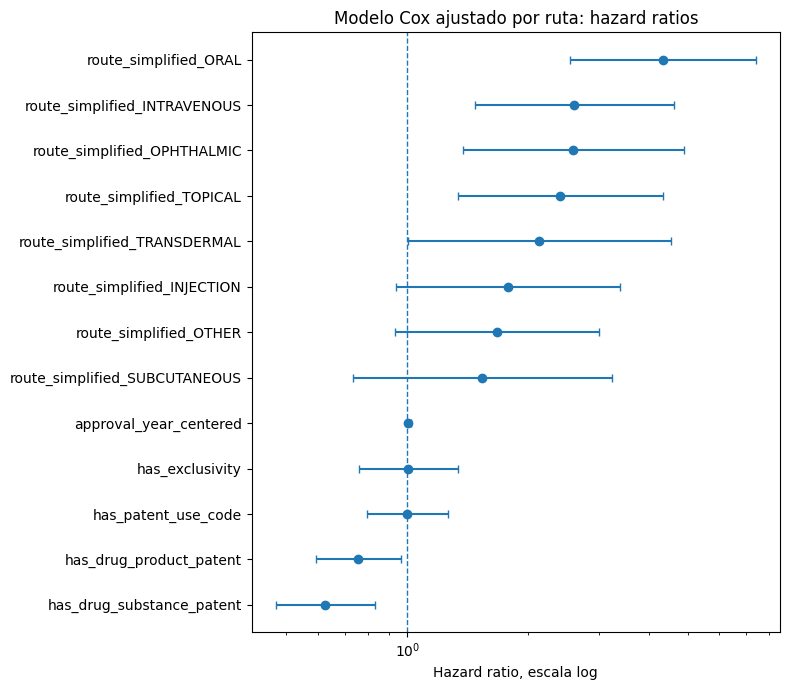

Figura guardada en: /Users/juanalbertomartinez/Desktop/Patente/figures/cox_route_forest_plot.png


,variable,HR,HR_lower,HR_upper,p
1,has_drug_substance_patent,0.625355,0.470204,0.831700,1.252631e-03
2,has_drug_product_patent,0.754743,0.590810,0.964163,2.431878e-02
3,has_patent_use_code,1.000599,0.794207,1.260625,9.959488e-01
4,has_exclusivity,1.006010,0.757654,1.335778,9.669570e-01
0,approval_year_centered,1.006037,0.991175,1.021121,4.280194e-01
10,route_simplified_SUBCUTANEOUS,1.540566,0.732936,3.238131,2.542007e-01
9,route_simplified_OTHER,1.675062,0.931299,3.012815,8.501044e-02
5,route_simplified_INJECTION,1.782345,0.938876,3.383569,7.720933e-02
12,route_simplified_TRANSDERMAL,2.136474,1.002893,4.551354,4.913121e-02
11,route_simplified_TOPICAL,2.409378,1.340585,4.330275,3.283589e-03


In [20]:
# Forest plot del modelo Cox ajustado por ruta


# tabla para forest plot
forest_df = cox_route_summary.copy()

forest_df = forest_df.rename(columns={
    "exp(coef)": "HR",
    "exp(coef) lower 95%": "HR_lower",
    "exp(coef) upper 95%": "HR_upper"
})

forest_df = forest_df[
    ["variable", "HR", "HR_lower", "HR_upper", "p"]
].copy()

# Ordenar por HR para visualización
forest_df = forest_df.sort_values("HR")

# Crear figura
fig, ax = plt.subplots(figsize=(8, 7))

y_pos = np.arange(len(forest_df))

ax.errorbar(
    forest_df["HR"],
    y_pos,
    xerr=[
        forest_df["HR"] - forest_df["HR_lower"],
        forest_df["HR_upper"] - forest_df["HR"]
    ],
    fmt="o",
    capsize=3
)

ax.axvline(1, linestyle="--", linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(forest_df["variable"])
ax.set_xscale("log")
ax.set_xlabel("Hazard ratio, escala log")
ax.set_title("Modelo Cox ajustado por ruta: hazard ratios")

plt.tight_layout()

fig_path = FIGURES_DIR / "cox_route_forest_plot.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {fig_path}")

display(forest_df)



El forest plot se generó correctamente y resume visualmente los hazard ratios del modelo Cox ajustado por ruta de administración.

La línea vertical punteada marca $HR = 1$, que representa ausencia de asociación con el hazard de entrada genérica. Los puntos ubicados a la izquierda de esa línea indican menor hazard de entrada genérica, mientras que los puntos ubicados a la derecha indican mayor hazard.

Los resultados principales son consistentes con la tabla del modelo:

- `has_drug_substance_patent` tiene un hazard ratio aproximado de 0.63, con intervalo de confianza completamente por debajo de 1. Esto sugiere que las patentes de sustancia se asocian con entrada más tardía de genéricos.
- `has_drug_product_patent` tiene un hazard ratio aproximado de 0.75, también con intervalo de confianza por debajo de 1. Esto sugiere una asociación similar, aunque menos intensa.
- `has_patent_use_code`, `has_exclusivity` y `approval_year_centered` tienen intervalos de confianza que cruzan 1, por lo que no muestran una asociación clara en este modelo.
- Las rutas `ORAL`, `INTRAVENOUS`, `OPHTHALMIC`, `TOPICAL` y `TRANSDERMAL` aparecen con hazard ratios mayores que 1, lo que sugiere entrada genérica más rápida en comparación con la categoría de referencia omitida.

La variable con mayor hazard ratio fue `route_simplified_ORAL`, con \(HR \approx 4.35\). Esto indica que, comparada con la ruta de referencia, la ruta oral presenta una mayor velocidad de entrada genérica.

En conjunto, la figura comunica dos mensajes centrales del modelo:

1. Las patentes de sustancia y producto están asociadas con menor hazard de entrada genérica.
2. La ruta de administración tiene un papel importante en la dinámica de entrada de genéricos.

## 7. Revisión del supuesto de riesgos proporcionales

El modelo Cox asume que los hazard ratios son constantes en el tiempo. A este supuesto se le conoce como supuesto de riesgos proporcionales.

En esta sección se realizará una revisión diagnóstica usando las herramientas de `lifelines`.

La prueba evalúa si los residuos de Schoenfeld muestran evidencia de que el efecto de alguna covariable cambia con el tiempo. Si una variable viola fuertemente el supuesto, su hazard ratio no debería interpretarse como constante durante todo el seguimiento.

En esta primera revisión se aplicará el diagnóstico al modelo Cox ajustado por ruta, que hasta ahora es el modelo más completo e informativo.

La interpretación será:

- valores $p$ pequeños sugieren posible violación del supuesto de riesgos proporcionales;
- valores $p$ grandes no muestran evidencia clara contra el supuesto.

Este diagnóstico será exploratorio. Si aparecen violaciones importantes, en una versión posterior se podrían considerar interacciones con el tiempo, estratificación o modelos alternativos.

In [22]:
# Revisión del supuesto de riesgos proporcionales

print("=" * 80)
print("Diagnóstico de riesgos proporcionales para el modelo Cox ajustado por ruta")
print("=" * 80)

# check_assumptions imprime una revisión textual y puede generar recomendaciones
cox_route.check_assumptions(
    cox_route_df,
    p_value_threshold=0.05,
    show_plots=False
)

Diagnóstico de riesgos proporcionales para el modelo Cox ajustado por ruta
The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 1439 total observations, 580 right-censored observations>
         test_name = proportional_hazard_test

---
                                    test_statistic      p  -log2(p)
approval_year_centered        km             19.37 <0.005     16.50
                              rank           19.15 <0.005     16.34
has_drug_product_patent       km              6.34   0.01      6.41
                              rank            5.95   0.01      6.09
has_drug_substance_patent     km              2.92   0.09      3.52
                              rank            3.07   0.08      3.65
has_exclusivity               km             14.68 <0.005     12.94
                              rank           17.42 <0.005     15.03
has_patent_use_code           km              0.47   0.49      1.01
                              rank            0.70   0.40      1.32
route_simplified_INJECTION    km              5.31   0.02      5.56
                              rank            3.89   0.05      4.36
route_simplified_INTRAVENOUS  km              5.66   0.02      5.85
                              rank            3.37   0.07      3.91
route_simplified_OPHTHALMIC   km              2.35   0.13      3.00
                              rank            1.02   0.31      1.67
route_simplified_ORAL         km              9.35 <0.005      8.81
                              rank            6.18   0.01      6.28
route_simplified_OTHER        km              8.54 <0.005      8.17
                              rank            6.51   0.01      6.55
route_simplified_SUBCUTANEOUS km              0.20   0.66      0.61
                              rank            0.05   0.82      0.28
route_simplified_TOPICAL      km             17.59 <0.005     15.16
                              rank           13.38 <0.005     11.94
route_simplified_TRANSDERMAL  km              2.67   0.10      3.29
                              rank            1.50   0.22      2.18



1. Variable 'approval_year_centered' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'approval_year_centered' might be incorrect. That
is, there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'approval_year_centered' using pd.cut, and then specify it in
`strata=['approval_year_centered', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'has_drug_product_patent' failed the non-proportional test: p-value is 0.0118.

   Advice: with so few unique values (only 2), you can include `strata=['has_drug_product_patent',
...]` in the call in `.fit`. See documentation in link [E] below.

3. Variable 'has_exclusivity' failed the

[]



La función `check_assumptions` se ejecutó correctamente, pero la salida mostrada corresponde principalmente al mensaje general de advertencia de `lifelines`.

Ese mensaje recuerda que, cuando se evalúan muchas covariables al mismo tiempo, algunas pueden aparecer como significativas por azar. También señala que, con muchas observaciones, desviaciones pequeñas del supuesto de riesgos proporcionales pueden ser detectadas como estadísticamente significativas.

Por esta razón, la revisión del supuesto de riesgos proporcionales no debe basarse únicamente en valores \(p\). Es recomendable combinar:

- pruebas estadísticas;
- inspección visual de residuos;
- sentido práctico de las variables;
- comparación con modelos alternativos.

Para tener una tabla más clara de resultados, en la siguiente celda usaremos directamente `proportional_hazard_test`. Esto permitirá identificar qué covariables podrían violar el supuesto de riesgos proporcionales.

## Prueba tabular del supuesto de riesgos proporcionales

La función `check_assumptions` proporciona una revisión general, pero para documentar el diagnóstico en el notebook conviene construir una tabla explícita.

En esta celda se aplicará la prueba de proporcionalidad de riesgos mediante `proportional_hazard_test`.

La tabla resultante incluirá, para cada covariable:

- estadístico de prueba;
- valor \(p\);
- indicador de posible violación usando \(\alpha = 0.05\).

La interpretación será:

- `p < 0.05`: posible evidencia de violación del supuesto de riesgos proporcionales;
- `p >= 0.05`: no se detecta evidencia clara de violación.

Esta revisión es exploratoria. Si una variable viola el supuesto, no necesariamente se elimina de inmediato; puede considerarse estratificación, interacción con el tiempo o un modelo alternativo.

In [24]:
# Prueba tabular del supuesto de riesgos proporcionales

from lifelines.statistics import proportional_hazard_test

ph_test = proportional_hazard_test(
    cox_route,
    cox_route_df,
    time_transform="rank"
)

ph_test_summary = ph_test.summary.reset_index().rename(
    columns={"index": "variable"}
)

ph_test_summary["possible_violation_0_05"] = ph_test_summary["p"] < 0.05

ph_test_summary = ph_test_summary.sort_values("p")

print("=" * 80)
print("Prueba de proporcionalidad de riesgos")
print("=" * 80)

display(ph_test_summary)

print("\nVariables con posible violación del supuesto PH (p < 0.05):")
display(
    ph_test_summary.loc[
        ph_test_summary["possible_violation_0_05"],
        ["variable", "test_statistic", "p"]
    ]
)

Prueba de proporcionalidad de riesgos


,variable,test_statistic,p,-log2(p),possible_violation_0_05
0,approval_year_centered,19.149124,0.000012,16.335910,True
3,has_exclusivity,17.420990,0.000030,15.027083,True
11,route_simplified_TOPICAL,13.380545,0.000254,11.941477,True
9,route_simplified_OTHER,6.513328,0.010707,6.545316,True
8,route_simplified_ORAL,6.181424,0.012910,6.275386,True
1,has_drug_product_patent,5.951807,0.014702,6.087823,True
5,route_simplified_INJECTION,3.887277,0.048653,4.361320,True
6,route_simplified_INTRAVENOUS,3.371790,0.066322,3.914376,False
2,has_drug_substance_patent,3.066642,0.079914,3.645401,False
12,route_simplified_TRANSDERMAL,1.501541,0.220434,2.181578,False



Variables con posible violación del supuesto PH (p < 0.05):


,variable,test_statistic,p
0,approval_year_centered,19.149124,0.000012
3,has_exclusivity,17.420990,0.000030
11,route_simplified_TOPICAL,13.380545,0.000254
9,route_simplified_OTHER,6.513328,0.010707
8,route_simplified_ORAL,6.181424,0.012910
1,has_drug_product_patent,5.951807,0.014702
5,route_simplified_INJECTION,3.887277,0.048653


### Interpretación de la prueba de proporcionalidad de riesgos

La prueba tabular del supuesto de riesgos proporcionales indica que algunas covariables podrían violar el supuesto PH.

Las variables con $p < 0.05$ fueron:

- `approval_year_centered`;
- `has_exclusivity`;
- `route_simplified_TOPICAL`;
- `route_simplified_OTHER`;
- `route_simplified_ORAL`;
- `has_drug_product_patent`;
- `route_simplified_INJECTION`.

Esto sugiere que el efecto de estas variables podría no ser constante durante todo el periodo de seguimiento. En otras palabras, el hazard ratio estimado para estas covariables puede cambiar con el tiempo.

Este resultado no invalida el modelo, pero sí indica que debemos interpretarlo con cautela. En particular, el modelo Cox ajustado por ruta es útil como análisis exploratorio, pero algunas asociaciones no deberían reportarse como efectos constantes sin una revisión adicional.

Hay tres formas comunes de proceder:

1. **Mantener el modelo como exploratorio**, aclarando que algunas variables muestran posible violación del supuesto PH.
2. **Estratificar por variables problemáticas**, especialmente por `route_simplified`, para permitir diferentes hazards base por ruta.
3. **Usar modelos alternativos**, como AFT, que no requieren el supuesto de riesgos proporcionales en la misma forma.

Como `route_simplified` aparece repetidamente entre las variables con posible violación, una estrategia razonable es ajustar un modelo Cox estratificado por ruta. Esto permite que cada ruta tenga su propia función de riesgo base, sin estimar un hazard ratio fijo para cada ruta.

El siguiente paso será ajustar un modelo Cox estratificado por `route_simplified`.

## Modelo Cox estratificado por ruta de administración

Dado que varias categorías de `route_simplified` mostraron posible violación del supuesto de riesgos proporcionales, ajustaremos un modelo Cox estratificado por ruta.

La estratificación permite que cada categoría de ruta tenga su propia función de riesgo base:

$$
h_k(t \mid X) = h_{0k}(t)\exp(\beta^\top X),
$$

donde $k$ representa la ruta de administración.

Con este enfoque, ya no se estima un hazard ratio para cada ruta. En cambio, la ruta se usa para permitir diferencias estructurales en el baseline hazard entre grupos.

El modelo incluirá como covariables:

- `approval_year_centered`;
- `has_drug_substance_patent`;
- `has_drug_product_patent`;
- `has_patent_use_code`;
- `has_exclusivity`.

y usará `route_simplified` como variable de estratificación.

Este modelo puede ser más apropiado si la ruta afecta la forma temporal del riesgo de entrada genérica.

In [26]:
# Modelo Cox estratificado por ruta de administración


cox_strata_cols = [
    "time_to_generic_years",
    "event",
    "approval_year_centered",
    "has_drug_substance_patent",
    "has_drug_product_patent",
    "has_patent_use_code",
    "has_exclusivity",
    "route_simplified"
]

cox_strata_df = modeling_dataset[cox_strata_cols].dropna().copy()

print("=" * 80)
print("Dataset para Cox estratificado por ruta")
print("=" * 80)
print(f"Filas: {cox_strata_df.shape[0]:,}")
print(f"Columnas: {cox_strata_df.shape[1]:,}")

print("\nTamaño de estratos:")
display(
    cox_strata_df["route_simplified"]
    .value_counts()
    .rename_axis("route_simplified")
    .reset_index(name="n")
)

cox_stratified = CoxPHFitter()

cox_stratified.fit(
    cox_strata_df,
    duration_col="time_to_generic_years",
    event_col="event",
    strata=["route_simplified"]
)

print("\n" + "=" * 80)
print("Resumen del modelo Cox estratificado por ruta")
print("=" * 80)

cox_stratified.print_summary()

cox_stratified_summary = (
    cox_stratified
    .summary
    .reset_index()
    .rename(columns={"covariate": "variable"})
)

print("\nResumen tabular:")
display(
    cox_stratified_summary[
        [
            "variable", "coef", "exp(coef)", "se(coef)",
            "z", "p", "coef lower 95%", "coef upper 95%",
            "exp(coef) lower 95%", "exp(coef) upper 95%"
        ]
    ]
)

print("\nConcordancia del modelo:")
print(cox_stratified.concordance_index_)

Dataset para Cox estratificado por ruta
Filas: 1,439
Columnas: 8

Tamaño de estratos:


,route_simplified,n
0,ORAL,841
1,INTRAVENOUS,157
2,OTHER,134
3,TOPICAL,100
4,INHALATION,51
5,INJECTION,50
6,OPHTHALMIC,49
7,SUBCUTANEOUS,36
8,TRANSDERMAL,21



Resumen del modelo Cox estratificado por ruta


<lifelines.CoxPHFitter: fitted with 1439 total observations, 580 right-censored observations>
             duration col = 'time_to_generic_years'
                event col = 'event'
                   strata = route_simplified
      baseline estimation = breslow
   number of observations = 1439
number of events observed = 859
   partial log-likelihood = -4489.73
         time fit was run = 2026-06-26 06:42:54 UTC

---
                           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                  
approval_year_centered     0.01      1.01      0.01           -0.01            0.02                0.99                1.02
has_drug_substance_patent -0.46      0.63      0.15           -0.75           -0.18                0.47                0.84
has_drug_product_patent   -0.31      0.73      0.13           -0.55           -0.06                0.57                0.94
has_patent_use_code        0.02      1.02      0.12           -0.21            0.25                0.81                1.28
has_exclusivity           -0.00      1.00      0.14           -0.29            0.28                0.75                1.32

                           cmp to     z      p  -log2(p)
covariate                                               
approval_year_centered       0.00  1.06   0.29      1.78
has_drug_substance_patent    0.00 -3.18 <0.005      9.40
has_drug_product_patent      0.00 -2.46   0.01      6.18
has_patent_use_code          0.00  0.15   0.88      0.18
has_exclusivity              0.00 -0.03   0.98      0.03
---
Concordance = 0.59
Partial AIC = 8989.47
log-likelihood ratio test = 43.36 on 5 df
-log2(p) of ll-ratio test = 24.93


Resumen tabular:


,variable,coef,exp(coef),se(coef),z,p,coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%
0,approval_year_centered,0.008052,1.008084,0.007626,1.055871,0.291027,-0.006894,0.022997,0.993129,1.023264
1,has_drug_substance_patent,-0.464536,0.628427,0.146156,-3.178353,0.001481,-0.750997,-0.178075,0.471896,0.836880
2,has_drug_product_patent,-0.308611,0.734466,0.125274,-2.463488,0.013759,-0.554143,-0.063078,0.574564,0.938870
3,has_patent_use_code,0.017599,1.017755,0.118615,0.148370,0.882051,-0.214882,0.250080,0.806636,1.284128
4,has_exclusivity,-0.004342,0.995667,0.144662,-0.030016,0.976054,-0.287875,0.279190,0.749856,1.322059



Concordancia del modelo:
0.592712813020844


El modelo Cox estratificado por ruta de administración se ajustó correctamente.

A diferencia del modelo anterior, aquí `route_simplified` no aparece como covariable con hazard ratios propios. En su lugar, se usa como variable de estratificación, lo que permite que cada ruta de administración tenga su propia función de riesgo base. Esto es útil porque la prueba de proporcionalidad sugería que varias categorías de ruta podían violar el supuesto de riesgos proporcionales.

Los resultados principales son consistentes con el modelo ajustado por ruta mediante dummies:

- `has_drug_substance_patent` tiene un hazard ratio aproximado de 0.63, con valor \(p = 0.0015\).
- `has_drug_product_patent` tiene un hazard ratio aproximado de 0.73, con valor \(p = 0.0138\).

Ambas variables se mantienen asociadas con menor hazard de entrada genérica. En términos prácticos, las unidades con patente de sustancia o patente de producto tienden a presentar una entrada más tardía de genéricos.

En cambio:

- `has_patent_use_code` no muestra asociación clara.
- `has_exclusivity` tampoco muestra asociación clara.
- `approval_year_centered` no resulta significativo en esta especificación.

La concordancia del modelo estratificado fue aproximadamente 0.59. Es menor que la del modelo con dummies de ruta, pero esto es esperable porque la estratificación ya no usa la ruta para ordenar riesgos individuales mediante coeficientes, sino para permitir hazards base distintos por estrato.

Este modelo es útil como análisis de robustez: confirma que la asociación de las patentes de sustancia y producto persiste incluso cuando permitimos que la dinámica base del riesgo varíe entre rutas de administración.

## Modelo AFT Weibull

Además del modelo Cox, ajustaremos un modelo AFT, o accelerated failure time.

A diferencia del modelo Cox, que modela el hazard de entrada genérica, los modelos AFT modelan directamente el tiempo hasta el evento. En esta formulación, los coeficientes se interpretan como efectos sobre la duración del tiempo hasta genérico.

En términos generales:

- coeficientes positivos se asocian con tiempos más largos hasta genérico;
- coeficientes negativos se asocian con tiempos más cortos hasta genérico.

En este primer modelo AFT usaremos la distribución Weibull e incluiremos las mismas covariables del modelo Cox estratificado, excepto la estratificación por ruta. Para incorporar la ruta, usaremos variables dummy de `route_simplified`, igual que en el modelo Cox ajustado por ruta.

Este modelo permitirá contrastar si las conclusiones sobre patentes de sustancia y producto son consistentes bajo una formulación alternativa.

In [28]:
# Modelo AFT Weibull

try:
    from lifelines import WeibullAFTFitter
except ImportError as e:
    raise ImportError(
        "La clase WeibullAFTFitter no está disponible. "
        "Verifica tu instalación de lifelines."
    ) from e


aft_base_cols = [
    "time_to_generic_years",
    "event",
    "approval_year_centered",
    "has_drug_substance_patent",
    "has_drug_product_patent",
    "has_patent_use_code",
    "has_exclusivity",
    "route_simplified"
]

aft_df = modeling_dataset[aft_base_cols].dropna().copy()

# Codificar ruta con dummies
aft_df = pd.get_dummies(
    aft_df,
    columns=["route_simplified"],
    drop_first=True,
    dtype=int
)

print("=" * 80)
print("Dataset para Weibull AFT")
print("=" * 80)
print(f"Filas: {aft_df.shape[0]:,}")
print(f"Columnas: {aft_df.shape[1]:,}")

weibull_aft = WeibullAFTFitter()

weibull_aft.fit(
    aft_df,
    duration_col="time_to_generic_years",
    event_col="event"
)

print("\n" + "=" * 80)
print("Resumen del modelo Weibull AFT")
print("=" * 80)

weibull_aft.print_summary()

weibull_aft_summary = (
    weibull_aft
    .summary
    .reset_index()
    .rename(columns={"covariate": "variable"})
)

print("\nResumen tabular:")
display(
    weibull_aft_summary[
        [
            "param", "variable", "coef", "exp(coef)", "se(coef)",
            "z", "p", "coef lower 95%", "coef upper 95%",
            "exp(coef) lower 95%", "exp(coef) upper 95%"
        ]
    ]
)

print("\nLog-likelihood:")
print(weibull_aft.log_likelihood_)

print("\nAIC:")
print(weibull_aft.AIC_)

Dataset para Weibull AFT
Filas: 1,439
Columnas: 15

Resumen del modelo Weibull AFT


<lifelines.WeibullAFTFitter: fitted with 1439 total observations, 580 right-censored observations>
             duration col = 'time_to_generic_years'
                event col = 'event'
   number of observations = 1439
number of events observed = 859
           log-likelihood = -3203.39
         time fit was run = 2026-06-26 06:44:22 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                      
lambda_ approval_year_centered        -0.01      0.99      0.00           -0.02            0.00                0.98                1.00
        has_drug_product_patent        0.17      1.19      0.08            0.02            0.33                1.02                1.39
        has_drug_substance_patent      0.30      1.34      0.09            0.12            0.47                1.13                1.61
        has_exclusivity               -0.01      0.99      0.09           -0.18            0.17                0.83                1.19
        has_patent_use_code           -0.00      1.00      0.07           -0.14            0.14                0.87                1.15
        route_simplified_INJECTION    -0.34      0.71      0.20           -0.74            0.06                0.48                1.06
        route_simplified_INTRAVENOUS  -0.59      0.55      0.18           -0.95           -0.24                0.39                0.79
        route_simplified_OPHTHALMIC   -0.60      0.55      0.20           -0.99           -0.20                0.37                0.82
        route_simplified_ORAL         -0.92      0.40      0.17           -1.26           -0.59                0.29                0.55
        route_simplified_OTHER        -0.31      0.73      0.19           -0.67            0.06                0.51                1.06
        route_simplified_SUBCUTANEOUS -0.27      0.76      0.24           -0.73            0.19                0.48                1.21
        route_simplified_TOPICAL      -0.54      0.58      0.19           -0.90           -0.17                0.40                0.84
        route_simplified_TRANSDERMAL  -0.48      0.62      0.24           -0.95           -0.01                0.39                0.99
        Intercept                      3.44     31.17      0.17            3.11            3.77               22.38               43.42
rho_    Intercept                      0.48      1.61      0.03            0.42            0.53                1.52                1.70

                                       cmp to     z      p  -log2(p)
param   covariate                                                   
lambda_ approval_year_centered           0.00 -1.56   0.12      3.09
        has_drug_product_patent          0.00  2.22   0.03      5.25
        has_drug_substance_patent        0.00  3.27 <0.005      9.85
        has_exclusivity                  0.00 -0.06   0.95      0.07
        has_patent_use_code              0.00 -0.01   0.99      0.01
        route_simplified_INJECTION       0.00 -1.69   0.09      3.46
        route_simplified_INTRAVENOUS     0.00 -3.28 <0.005      9.92
        route_simplified_OPHTHALMIC      0.00 -2.95 <0.005      8.32
        route_simplified_ORAL            0.00 -5.44 <0.005     24.14
        route_simplified_OTHER           0.00 -1.66   0.10      3.38
        route_simplified_SUBCUTANEOUS    0.00 -1.16   0.25      2.02
        route_simplified_TOPICAL         0.00 -2.90 <0.005      8.05
        route_simplified_TRANSDERMAL     0.00 -2.00   0.05      4.44
        Intercept                        0.00 20.34 <0.005    303.09
rho_    Intercept                        0.00 16.23 <0.005    194.34
---
Concordance = 0.64
AIC = 6436.79
log-likelihood ratio test = 167.00 on 13 df
-log2(p) of ll-ratio test = 93.43


Resumen tabular:


,param,variable,coef,exp(coef),se(coef),z,p,coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%
0,lambda_,approval_year_centered,-0.007228,0.992798,0.004620,-1.564525,1.176943e-01,-0.016282,0.001827,0.983850,1.001828
1,lambda_,has_drug_product_patent,0.173169,1.189067,0.077976,2.220802,2.636439e-02,0.020339,0.325999,1.020547,1.385414
2,lambda_,has_drug_substance_patent,0.296242,1.344796,0.090673,3.267166,1.086299e-03,0.118527,0.473957,1.125838,1.606338
3,lambda_,has_exclusivity,-0.005615,0.994400,0.089953,-0.062424,9.502250e-01,-0.181920,0.170690,0.833668,1.186123
4,lambda_,has_patent_use_code,-0.000515,0.999486,0.073451,-0.007005,9.944106e-01,-0.144476,0.143447,0.865476,1.154246
5,lambda_,route_simplified_INJECTION,-0.343500,0.709283,0.203330,-1.689372,9.114822e-02,-0.742020,0.055020,0.476151,1.056561
6,lambda_,route_simplified_INTRAVENOUS,-0.594444,0.551869,0.181161,-3.281295,1.033315e-03,-0.949514,-0.239374,0.386929,0.787120
7,lambda_,route_simplified_OPHTHALMIC,-0.596956,0.550485,0.202076,-2.954116,3.135663e-03,-0.993018,-0.200894,0.370457,0.817999
8,lambda_,route_simplified_ORAL,-0.922630,0.397472,0.169691,-5.437107,5.415271e-08,-1.255219,-0.590041,0.285014,0.554305
9,lambda_,route_simplified_OTHER,-0.309782,0.733607,0.186210,-1.663619,9.618864e-02,-0.674746,0.055182,0.509286,1.056733



Log-likelihood:
-3203.392970967575

AIC:
6436.78594193515



El modelo Weibull AFT se ajustó correctamente usando 1,439 unidades y 859 eventos observados.

En un modelo AFT, los coeficientes del parámetro `lambda_` se interpretan sobre el tiempo hasta el evento. Por ello, la lectura es distinta al modelo Cox:

- `exp(coef) > 1`: se asocia con tiempos más largos hasta genérico.
- `exp(coef) < 1`: se asocia con tiempos más cortos hasta genérico.

Los resultados son consistentes con los modelos Cox. En particular:

- `has_drug_substance_patent` tuvo `exp(coef) ≈ 1.34`, con valor \(p \approx 0.0011\).
- `has_drug_product_patent` tuvo `exp(coef) ≈ 1.19`, con valor \(p \approx 0.026\).

Esto sugiere que las patentes de sustancia y de producto se asocian con un alargamiento del tiempo hasta la entrada de genéricos. Esta conclusión coincide con los modelos Cox, donde estas variables tenían hazard ratios menores que 1.

En cambio:

- `has_exclusivity` no mostró asociación clara.
- `has_patent_use_code` tampoco mostró asociación clara.
- `approval_year_centered` no fue significativo en esta especificación.

Las variables de ruta muestran coeficientes negativos para varias rutas, especialmente `ORAL`, `INTRAVENOUS`, `OPHTHALMIC` y `TOPICAL`. En el marco AFT, esto indica tiempos más cortos hasta genérico en comparación con la categoría de referencia. Este resultado es consistente con el modelo Cox, donde esas rutas mostraban mayor hazard de entrada genérica.

El modelo Weibull AFT alcanzó una concordancia aproximada de 0.64, similar al modelo Cox ajustado por ruta. Esto sugiere que ambos enfoques capturan patrones comparables.

En conjunto, el modelo AFT refuerza la interpretación principal del análisis: las patentes de sustancia y producto parecen asociarse con una entrada más tardía de genéricos, mientras que algunas rutas de administración, especialmente la vía oral, se asocian con entrada más rápida.

## Modelo AFT Log-Logistic

Para evaluar la robustez del modelo AFT, ajustaremos un segundo modelo paramétrico usando una distribución Log-Logistic.

El modelo Log-Logistic también pertenece a la familia AFT, pero permite una forma distinta de la función de riesgo. Esto puede ser útil cuando el hazard no es monótono o cuando los tiempos al evento presentan colas más pesadas.

Usaremos las mismas covariables del modelo Weibull AFT:

- variables de patente;
- exclusividad;
- año de aprobación centrado;
- ruta de administración simplificada.

Después compararemos los modelos Weibull y Log-Logistic usando:

- log-likelihood;
- AIC;
- concordancia.

Un AIC menor indica mejor balance entre ajuste y complejidad del modelo.

In [30]:
#  Modelo AFT Log-Logistic


try:
    from lifelines import LogLogisticAFTFitter
except ImportError as e:
    raise ImportError(
        "La clase LogLogisticAFTFitter no está disponible. "
        "Verifica tu instalación de lifelines."
    ) from e


loglogistic_aft = LogLogisticAFTFitter()

loglogistic_aft.fit(
    aft_df,
    duration_col="time_to_generic_years",
    event_col="event"
)

print("=" * 80)
print("Resumen del modelo Log-Logistic AFT")
print("=" * 80)

loglogistic_aft.print_summary()

loglogistic_aft_summary = (
    loglogistic_aft
    .summary
    .reset_index()
    .rename(columns={"covariate": "variable"})
)

print("\nResumen tabular:")
display(
    loglogistic_aft_summary[
        [
            "param", "variable", "coef", "exp(coef)", "se(coef)",
            "z", "p", "coef lower 95%", "coef upper 95%",
            "exp(coef) lower 95%", "exp(coef) upper 95%"
        ]
    ]
)

print("\nLog-likelihood:")
print(loglogistic_aft.log_likelihood_)

print("\nAIC:")
print(loglogistic_aft.AIC_)

Resumen del modelo Log-Logistic AFT


<lifelines.LogLogisticAFTFitter: fitted with 1439 total observations, 580 right-censored observations>
             duration col = 'time_to_generic_years'
                event col = 'event'
   number of observations = 1439
number of events observed = 859
           log-likelihood = -3195.80
         time fit was run = 2026-06-26 06:48:57 UTC

---
                                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                      
alpha_ approval_year_centered        -0.01      0.99      0.00           -0.02            0.00                0.98                1.00
       has_drug_product_patent        0.20      1.23      0.08            0.05            0.36                1.05                1.43
       has_drug_substance_patent      0.30      1.36      0.09            0.14            0.47                1.15                1.60
       has_exclusivity                0.09      1.10      0.09           -0.08            0.26                0.93                1.30
       has_patent_use_code            0.03      1.04      0.08           -0.11            0.18                0.89                1.20
       route_simplified_INJECTION    -0.39      0.68      0.20           -0.77           -0.00                0.46                1.00
       route_simplified_INTRAVENOUS  -0.65      0.52      0.17           -0.98           -0.32                0.38                0.73
       route_simplified_OPHTHALMIC   -0.60      0.55      0.19           -0.98           -0.22                0.37                0.80
       route_simplified_ORAL         -0.99      0.37      0.15           -1.29           -0.68                0.28                0.51
       route_simplified_OTHER        -0.38      0.68      0.17           -0.72           -0.04                0.49                0.96
       route_simplified_SUBCUTANEOUS -0.26      0.77      0.22           -0.69            0.18                0.50                1.19
       route_simplified_TOPICAL      -0.69      0.50      0.18           -1.04           -0.35                0.35                0.71
       route_simplified_TRANSDERMAL  -0.51      0.60      0.24           -0.97           -0.04                0.38                0.96
       Intercept                      3.20     24.52      0.15            2.90            3.50               18.13               33.17
beta_  Intercept                      0.75      2.12      0.03            0.69            0.81                2.00                2.24

                                      cmp to     z      p  -log2(p)
param  covariate                                                   
alpha_ approval_year_centered           0.00 -1.71   0.09      3.52
       has_drug_product_patent          0.00  2.62   0.01      6.81
       has_drug_substance_patent        0.00  3.56 <0.005     11.40
       has_exclusivity                  0.00  1.07   0.28      1.82
       has_patent_use_code              0.00  0.46   0.64      0.64
       route_simplified_INJECTION       0.00 -1.98   0.05      4.38
       route_simplified_INTRAVENOUS     0.00 -3.86 <0.005     13.08
       route_simplified_OPHTHALMIC      0.00 -3.09 <0.005      8.98
       route_simplified_ORAL            0.00 -6.37 <0.005     32.29
       route_simplified_OTHER           0.00 -2.19   0.03      5.14
       route_simplified_SUBCUTANEOUS    0.00 -1.16   0.24      2.03
       route_simplified_TOPICAL         0.00 -3.92 <0.005     13.44
       route_simplified_TRANSDERMAL     0.00 -2.12   0.03      4.87
       Intercept                        0.00 20.77 <0.005    315.89
beta_  Intercept                        0.00 25.44 <0.005    471.71
---
Concordance = 0.64
AIC = 6421.59
log-likelihood ratio test = 170.09 on 13 df
-log2(p) of ll-ratio test = 95.51


Resumen tabular:


,param,variable,coef,exp(coef),se(coef),z,p,coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%
0,alpha_,approval_year_centered,-0.008192,0.991841,0.004792,-1.709508,8.735685e-02,-0.017585,0.001200,0.982568,1.001201
1,alpha_,has_drug_product_patent,0.204814,1.227297,0.078282,2.616346,8.887633e-03,0.051383,0.358245,1.052726,1.430816
2,alpha_,has_drug_substance_patent,0.304746,1.356281,0.085597,3.560232,3.705274e-04,0.136979,0.472514,1.146804,1.604022
3,alpha_,has_exclusivity,0.092875,1.097324,0.086554,1.073020,2.832620e-01,-0.076769,0.262518,0.926104,1.300200
4,alpha_,has_patent_use_code,0.034889,1.035504,0.075085,0.464652,6.421808e-01,-0.112276,0.182053,0.893797,1.199678
5,alpha_,route_simplified_INJECTION,-0.387525,0.678735,0.196082,-1.976342,4.811608e-02,-0.771838,-0.003211,0.462163,0.996794
6,alpha_,route_simplified_INTRAVENOUS,-0.649337,0.522392,0.168398,-3.855977,1.152684e-04,-0.979391,-0.319284,0.375540,0.726669
7,alpha_,route_simplified_OPHTHALMIC,-0.600636,0.548463,0.194145,-3.093755,1.976405e-03,-0.981153,-0.220120,0.374879,0.802423
8,alpha_,route_simplified_ORAL,-0.986436,0.372903,0.154875,-6.369235,1.899730e-10,-1.289986,-0.682886,0.275275,0.505157
9,alpha_,route_simplified_OTHER,-0.380517,0.683508,0.173558,-2.192453,2.834685e-02,-0.720683,-0.040350,0.486420,0.960453



Log-likelihood:
-3195.7956724652827

AIC:
6421.591344930565




El modelo Log-Logistic AFT se ajustó correctamente usando 1,439 unidades y 859 eventos observados.

Al igual que en el modelo Weibull AFT, los coeficientes del parámetro `alpha_` se interpretan en términos del tiempo hasta entrada genérica:

- `exp(coef) > 1`: tiempos más largos hasta genérico.
- `exp(coef) < 1`: tiempos más cortos hasta genérico.

Los resultados son muy consistentes con el modelo Weibull AFT y con los modelos Cox. Las variables de patente siguen mostrando una asociación clara con tiempos más largos hasta genérico:

- `has_drug_substance_patent` tiene `exp(coef) ≈ 1.36`, con valor \(p < 0.001\).
- `has_drug_product_patent` tiene `exp(coef) ≈ 1.23`, con valor \(p \approx 0.0089\).

Esto sugiere que la presencia de patentes de sustancia y de producto se asocia con un retraso en la entrada de genéricos.

En cambio:

- `has_exclusivity` no muestra asociación clara;
- `has_patent_use_code` tampoco muestra asociación clara;
- `approval_year_centered` no alcanza significancia convencional.

Las rutas de administración también muestran un patrón consistente con los modelos anteriores. Algunas rutas, especialmente `ORAL`, `INTRAVENOUS`, `OPHTHALMIC`, `TOPICAL` y `TRANSDERMAL`, presentan factores menores que 1, lo que indica tiempos más cortos hasta genérico en comparación con la categoría de referencia.

El modelo Log-Logistic AFT obtuvo:

- log-likelihood ≈ -3195.80;
- AIC ≈ 6421.59;
- concordancia ≈ 0.64.

El AIC del modelo Log-Logistic es menor que el del modelo Weibull AFT, por lo que, entre estos dos modelos paramétricos, el Log-Logistic ofrece un mejor balance entre ajuste y complejidad.

## Comparación de modelos de supervivencia

En esta sección construiremos una tabla resumen para comparar los modelos ajustados hasta ahora.

Los modelos considerados son:

1. Cox simple.
2. Cox con tipos específicos de patente.
3. Cox ajustado por ruta.
4. Cox estratificado por ruta.
5. Weibull AFT.
6. Log-Logistic AFT.

La comparación incluirá, cuando esté disponible:

- número de observaciones;
- número de eventos;
- concordancia;
- log-likelihood;
- AIC o partial AIC.

Esta tabla permitirá identificar qué modelos ofrecen mejor capacidad discriminativa y mejor ajuste relativo.

Hay que recordar que Cox y AFT no tienen exactamente la misma función de verosimilitud, por lo que sus AIC no siempre deben compararse de forma directa. Sin embargo, sí es razonable comparar AIC entre modelos AFT paramétricos, como Weibull y Log-Logistic.

In [32]:
# Comparación de modelos de supervivencia


def safe_getattr(obj, attr, default=np.nan):
    """
    Extrae un atributo de forma segura.
    Algunos atributos de lifelines existen como propiedades,
    pero pueden lanzar errores si no aplican al tipo de modelo.
    """
    try:
        return getattr(obj, attr)
    except Exception:
        return default


def safe_n_events(model):
    """
    Extrae número de eventos observados cuando está disponible.
    """
    try:
        return int(model.event_observed.sum())
    except Exception:
        return np.nan


def add_model_summary(name, model, model_type):
    """
    Extrae métricas disponibles de modelos lifelines.
    """
    row = {
        "model": name,
        "model_type": model_type,
        "n_observations": safe_getattr(model, "_n_examples"),
        "n_events": safe_n_events(model),
        "concordance": safe_getattr(model, "concordance_index_"),
        "log_likelihood": safe_getattr(model, "log_likelihood_"),
        "AIC": safe_getattr(model, "AIC_"),
        "partial_AIC": safe_getattr(model, "AIC_partial_"),
    }
    return row


model_comparison = []

model_comparison.append(add_model_summary("Cox simple", cox_simple, "Cox PH"))
model_comparison.append(add_model_summary("Cox patent types", cox_patent_type, "Cox PH"))
model_comparison.append(add_model_summary("Cox route adjusted", cox_route, "Cox PH"))
model_comparison.append(add_model_summary("Cox route stratified", cox_stratified, "Cox PH stratified"))
model_comparison.append(add_model_summary("Weibull AFT", weibull_aft, "AFT"))
model_comparison.append(add_model_summary("Log-Logistic AFT", loglogistic_aft, "AFT"))

model_comparison_df = pd.DataFrame(model_comparison)

# Ordenar columnas
model_comparison_df = model_comparison_df[
    [
        "model",
        "model_type",
        "n_observations",
        "n_events",
        "concordance",
        "log_likelihood",
        "AIC",
        "partial_AIC"
    ]
]

print("=" * 80)
print("Comparación de modelos")
print("=" * 80)

display(model_comparison_df)

# Guardar tabla
model_comparison_path = TABLES_DIR / "model_comparison_survival.csv"
model_comparison_df.to_csv(model_comparison_path, index=False)

print(f"Tabla guardada en: {model_comparison_path}")

Comparación de modelos


,model,model_type,n_observations,n_events,concordance,log_likelihood,AIC,partial_AIC
0,Cox simple,Cox PH,1439,859,0.566068,-5642.669912,NaN,11295.339824
1,Cox patent types,Cox PH,1439,859,0.572770,-5640.060703,NaN,11290.121406
2,Cox route adjusted,Cox PH,1439,859,0.635418,-5573.711083,NaN,11173.422167
3,Cox route stratified,Cox PH stratified,1439,859,0.592713,-4489.734419,NaN,8989.468837
4,Weibull AFT,AFT,1439,859,0.635087,-3203.392971,6436.785942,NaN
5,Log-Logistic AFT,AFT,1439,859,0.639668,-3195.795672,6421.591345,NaN


Tabla guardada en: /Users/juanalbertomartinez/Desktop/Patente/tables/model_comparison_survival.csv




La comparación de modelos se generó correctamente y fue guardada en: tables/model_comparison_survival.csv


Todos los modelos fueron ajustados con la misma base de 1,439 unidades y 859 eventos observados.

En los modelos Cox, la concordancia fue:

* Cox simple: 0.566
* Cox con tipos de patente: 0.573
* Cox ajustado por ruta: 0.635
* Cox estratificado por ruta: 0.593

Esto muestra que incorporar la ruta de administración mejora claramente la capacidad discriminativa del modelo Cox. El modelo Cox ajustado por ruta fue el mejor entre los modelos Cox en términos de concordancia.

En los modelos AFT, la concordancia fue:

* Weibull AFT: 0.635
* Log-Logistic AFT: 0.640

Ambos modelos AFT tienen una concordancia similar al Cox ajustado por ruta. Entre los dos AFT, el modelo Log-Logistic presenta mejor desempeño relativo, ya que tiene menor AIC:

* Weibull AFT: AIC ≈ 6436.79
* Log-Logistic AFT: AIC ≈ 6421.59

Por lo tanto, dentro de los modelos paramétricos AFT, el Log-Logistic ofrece el mejor balance entre ajuste y complejidad.

Es importante recordar que el AIC de los modelos Cox no es directamente comparable con el AIC de los modelos AFT, porque Cox usa verosimilitud parcial, mientras que los AFT son modelos paramétricos completos. Por eso, para Cox se reporta `partial_AIC`, mientras que para AFT se reporta `AIC`.

En conjunto, la comparación sugiere que los modelos más útiles en esta etapa son:

* **Cox ajustado por ruta**, para interpretación mediante hazard ratios.
* **Cox estratificado por ruta**, como análisis de robustez ante posibles violaciones del supuesto PH.
* **Log-Logistic AFT**, como modelo paramétrico alternativo con buen ajuste relativo.

Los resultados principales son consistentes entre modelos: las patentes de sustancia y producto se asocian con entrada más tardía de genéricos, mientras que la ruta de administración explica una parte importante de la variabilidad en el tiempo hasta genérico.

## Guardado de resultados de modelos

En esta última sección se guardarán las tablas principales generadas en el notebook.

Se guardarán:

- resumen del modelo Cox simple;
- resumen del modelo Cox con tipos específicos de patente;
- resumen del modelo Cox ajustado por ruta;
- resumen del modelo Cox estratificado por ruta;
- resumen del modelo Weibull AFT;
- resumen del modelo Log-Logistic AFT;
- tabla comparativa de modelos;
- dataset final de modelado.


In [33]:
# Guardado de resultados de modelos


# Rutas para tablas
cox_simple_summary_path = TABLES_DIR / "cox_simple_summary.csv"
cox_patent_type_summary_path = TABLES_DIR / "cox_patent_type_summary.csv"
cox_route_summary_path = TABLES_DIR / "cox_route_adjusted_summary.csv"
cox_stratified_summary_path = TABLES_DIR / "cox_route_stratified_summary.csv"
weibull_aft_summary_path = TABLES_DIR / "weibull_aft_summary.csv"
loglogistic_aft_summary_path = TABLES_DIR / "loglogistic_aft_summary.csv"

# Ruta para dataset de modelado
modeling_dataset_path = DATA_INTERMEDIATE_DIR / "survival_modeling_dataset.parquet"
modeling_dataset_csv_path = DATA_INTERMEDIATE_DIR / "survival_modeling_dataset.csv"

# Guardar tablas de modelos Cox
cox_simple_summary.to_csv(cox_simple_summary_path, index=False)
cox_patent_type_summary.to_csv(cox_patent_type_summary_path, index=False)
cox_route_summary.to_csv(cox_route_summary_path, index=False)
cox_stratified_summary.to_csv(cox_stratified_summary_path, index=False)

# Guardar tablas AFT
weibull_aft_summary.to_csv(weibull_aft_summary_path, index=False)
loglogistic_aft_summary.to_csv(loglogistic_aft_summary_path, index=False)

# Guardar dataset de modelado
modeling_dataset.to_parquet(modeling_dataset_path, index=False)
modeling_dataset.to_csv(modeling_dataset_csv_path, index=False)

print("=" * 80)
print("Resultados de modelos guardados correctamente")
print("=" * 80)

print("Tablas Cox:")
print(f"- {cox_simple_summary_path}")
print(f"- {cox_patent_type_summary_path}")
print(f"- {cox_route_summary_path}")
print(f"- {cox_stratified_summary_path}")

print("\nTablas AFT:")
print(f"- {weibull_aft_summary_path}")
print(f"- {loglogistic_aft_summary_path}")

print("\nComparación de modelos:")
print(f"- {model_comparison_path}")

print("\nDataset de modelado:")
print(f"- {modeling_dataset_path}")
print(f"- {modeling_dataset_csv_path}")

Resultados de modelos guardados correctamente
Tablas Cox:
- /Users/juanalbertomartinez/Desktop/Patente/tables/cox_simple_summary.csv
- /Users/juanalbertomartinez/Desktop/Patente/tables/cox_patent_type_summary.csv
- /Users/juanalbertomartinez/Desktop/Patente/tables/cox_route_adjusted_summary.csv
- /Users/juanalbertomartinez/Desktop/Patente/tables/cox_route_stratified_summary.csv

Tablas AFT:
- /Users/juanalbertomartinez/Desktop/Patente/tables/weibull_aft_summary.csv
- /Users/juanalbertomartinez/Desktop/Patente/tables/loglogistic_aft_summary.csv

Comparación de modelos:
- /Users/juanalbertomartinez/Desktop/Patente/tables/model_comparison_survival.csv

Dataset de modelado:
- /Users/juanalbertomartinez/Desktop/Patente/data_intermediate/survival_modeling_dataset.parquet
- /Users/juanalbertomartinez/Desktop/Patente/data_intermediate/survival_modeling_dataset.csv


Los resultados principales del notebook `03_modelos_supervivencia_cox_aft.ipynb` fueron guardados correctamente.

Se generaron tablas para los modelos Cox:

- `cox_simple_summary.csv`
- `cox_patent_type_summary.csv`
- `cox_route_adjusted_summary.csv`
- `cox_route_stratified_summary.csv`

También se guardaron las tablas de los modelos AFT:

- `weibull_aft_summary.csv`
- `loglogistic_aft_summary.csv`

Además, se guardó la tabla comparativa:

- `model_comparison_survival.csv`

y el dataset final usado para modelado:

- `survival_modeling_dataset.parquet`
- `survival_modeling_dataset.csv`

Con esto queda completada la tercera fase del proyecto: ajuste y comparación de modelos de supervivencia.

Los resultados principales de este notebook pueden resumirse así:

1. Los modelos Cox muestran que las patentes de sustancia y de producto se asocian con menor hazard de entrada genérica, es decir, con entrada más tardía.
2. La ruta de administración mejora claramente la capacidad explicativa del modelo.
3. El modelo Cox ajustado por ruta alcanzó una concordancia aproximada de 0.635.
4. El modelo Cox estratificado por ruta confirmó que las asociaciones de patentes de sustancia y producto se mantienen al permitir hazards base distintos por ruta.
5. Los modelos AFT dieron resultados consistentes con Cox.
6. Entre los modelos AFT, el Log-Logistic presentó mejor ajuste que Weibull según AIC.
7. La exclusividad general y los códigos de uso de patente no mostraron una asociación clara en estas especificaciones preliminares.

Estos resultados son todavía exploratorios, pero ya forman una base sólida para redactar una primera sección de resultados.